# Kvasir Dataset - Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on the Kvasir gastrointestinal image dataset.

Tasks covered:
- Load dataset
- Inspect folder structure
- Count images per class
- Display sample images
- Analyze image resolution distribution
- Basic dataset statistics


In [4]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print('Libraries loaded successfully')

Libraries loaded successfully


## Set Dataset Path
Update the path below to where the Kvasir dataset is located.

In [5]:
DATASET_PATH = 'kvasir-dataset'

classes = sorted(os.listdir(DATASET_PATH))
print('Classes found:')
for c in classes:
    print(c)

Classes found:
dyed-lifted-polyps
dyed-resection-margins
esophagitis
normal-cecum
normal-pylorus
normal-z-line
polyps
ulcerative-colitis


## Count Images Per Class

In [6]:
class_counts = {}

for c in classes:
    path = os.path.join(DATASET_PATH, c)
    count = len(os.listdir(path))
    class_counts[c] = count

df = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Image_Count'])
df

,Class,Image_Count
0,dyed-lifted-polyps,500
1,dyed-resection-margins,500
2,esophagitis,500
3,normal-cecum,500
4,normal-pylorus,500
5,normal-z-line,500
6,polyps,500
7,ulcerative-colitis,500


## Plot Distribution of Images

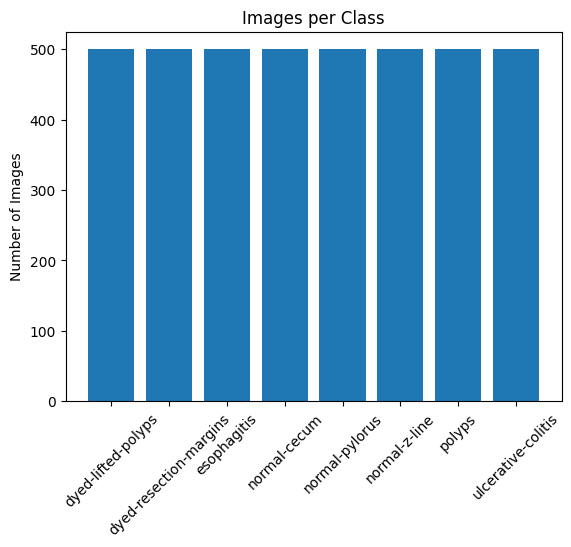

In [7]:
plt.figure()
plt.bar(df['Class'], df['Image_Count'])
plt.xticks(rotation=45)
plt.title('Images per Class')
plt.ylabel('Number of Images')
plt.show()

## Display Sample Images

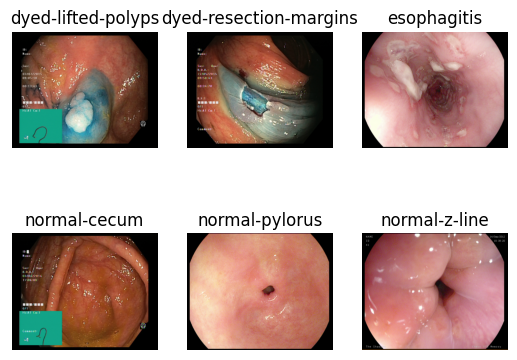

In [8]:
plt.figure()

i = 1
for c in classes[:6]:
    folder = os.path.join(DATASET_PATH, c)
    img_name = os.listdir(folder)[0]
    img_path = os.path.join(folder, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i)
    plt.imshow(img)
    plt.title(c)
    plt.axis('off')
    i += 1

plt.show()

## Image Resolution Analysis

In [9]:
widths = []
heights = []

for c in classes:
    folder = os.path.join(DATASET_PATH, c)
    for img_name in os.listdir(folder)[:50]:
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path)
        h, w, _ = img.shape
        widths.append(w)
        heights.append(h)

print('Average Width:', np.mean(widths))
print('Average Height:', np.mean(heights))

Average Width: 964.8
Average Height: 740.52


## Width Distribution

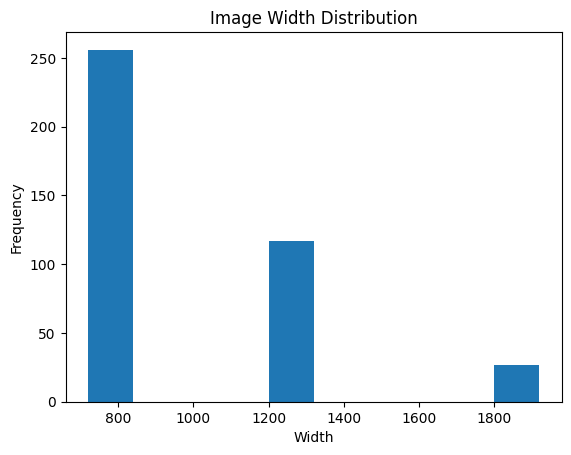

In [10]:
plt.figure()
plt.hist(widths)
plt.title('Image Width Distribution')
plt.xlabel('Width')
plt.ylabel('Frequency')
plt.show()

## Height Distribution

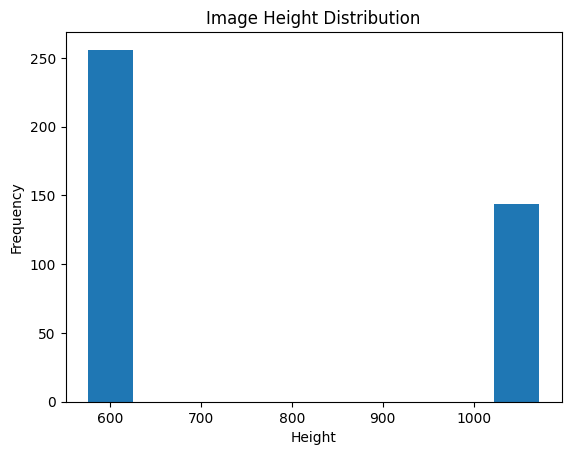

In [11]:
plt.figure()
plt.hist(heights)
plt.title('Image Height Distribution')
plt.xlabel('Height')
plt.ylabel('Frequency')
plt.show()

## Summary

This EDA notebook helps understand:
- Dataset structure
- Class distribution
- Image examples
- Image size statistics

These insights guide preprocessing steps before training ML models.